# Setup

This section sets up everything we need for our shorse/snarse analysis.

If you have any questions about what these blocks do, feel free to ask!

In [1]:
IMG_DIR = "images"

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
# Preprocesses the images for the models
def preprocess(img_path):
    preprocess_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Load image - size is ResNet standard
    img = Image.open(img_path)
    img = preprocess_transform(img)
    img = img.unsqueeze(0)

    return img

# Preprocess the images for plotting
def plot_preprocess(img_path):
    plot_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(), # Converts to [0, 1] range and (C, H, W)
    ])
    
    img = Image.open(img_path).convert('RGB') # Ensure 3 channels
    img = plot_transform(img)
    
    # Swap from (C, H, W) to (H, W, C) for Matplotlib
    return img.permute(1, 2, 0).numpy()

# Extracts features from preprocessed images
# Feature extractor = the ResNet50 model discussed below!
def extract_features(feature_extractor, img_path):
    img = preprocess(img_path)

    # Extract features with ResNet
    features = feature_extractor(img)

    return features.flatten().detach().numpy()

# Shorses and Snarses

First, we need a collection of shorses and snarses! We will use some images that our experts brought in.

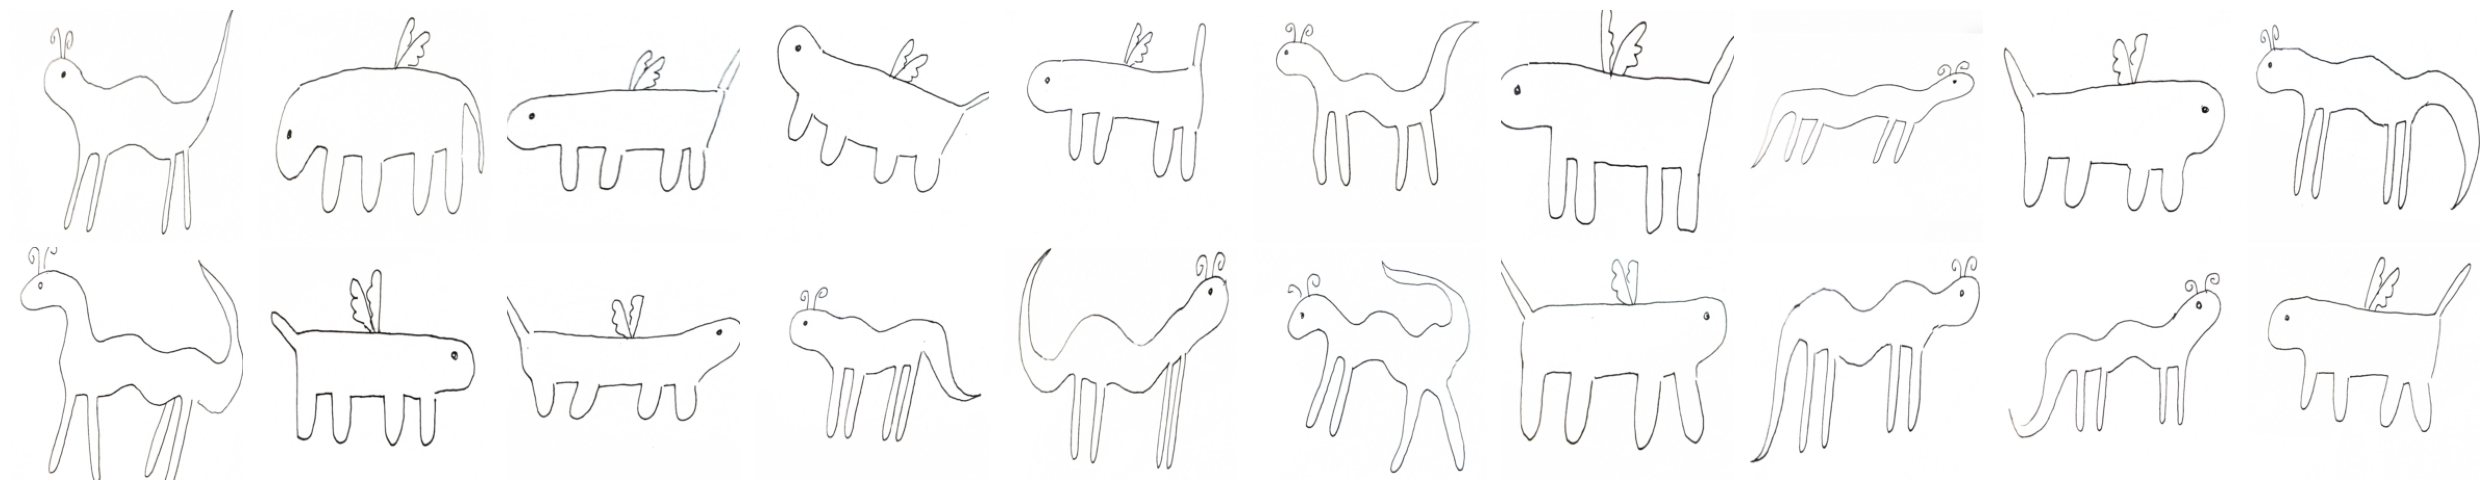

In [4]:
# Get images
image_names = os.listdir(IMG_DIR)
image_files = [os.path.join(os.getcwd(), IMG_DIR, f) for f in image_names]
image_list = [plot_preprocess(f) for f in image_files]

# Plot images
fig, axes = plt.subplots(2, 10, figsize=(25,5))
axes = axes.flatten()
for i in range(20):
    if i < len(image_list):
        axes[i].imshow(image_list[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# ResNet-50

ResNet-50 is a type of machine learning model that is designed to work well with images.

It can be used for _classification_, where the model tries to tell what the image is based on a set of labels.

We will use it to find clues in our images that we can give to another tool later on. This is called _feature extraction_.

In [5]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Remove the classification head
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor.eval()

print("ResNet loaded!")

ResNet loaded!


In [6]:
# Get features from images
features = np.array([extract_features(model, f) for f in image_files])

# Get best features
pca = PCA(n_components=0.95, random_state=42)
best_features = pca.fit_transform(features)

print("Features ready!")

Features ready!


# Hierarchical Clustering

_Clustering_ is a type of machine learning where the model groups the data based on _similarities and differences_.

&emsp; Imagine sorting a bowl of candy and think about the steps you would take. \
&emsp; You might put Skittles and Starburst together because they are both fruit. \
&emsp; Then you might put M&Ms and Reese's together because they are both chocolate. \
&emsp; Now you have two _clusters_: fruit and chocolate!

_Hierarchical clustering_ lets us see how the model creates groups. It creates a graph called a _dendrogram_, which looks like an upside-down tree.

We can see which pictures are most similar by looking at how closely connected they are. We can also pick a level of the tree and use the branches to make our groups!

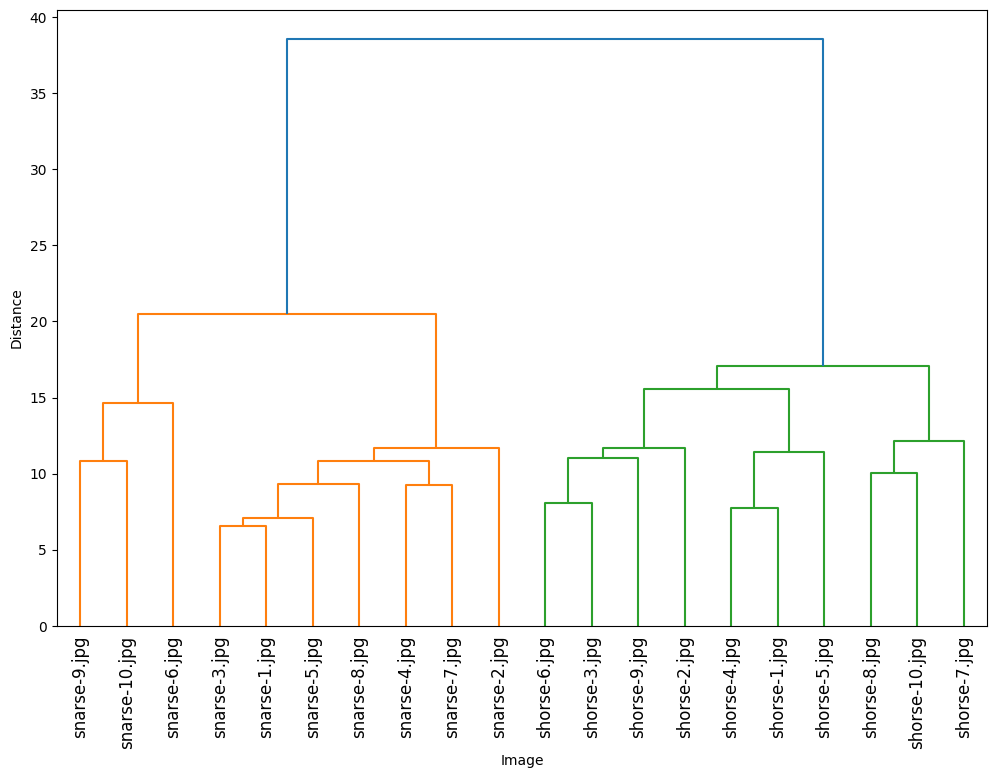

In [7]:
linked = linkage(best_features, method='ward')

plt.figure(figsize=(12,8))
dendrogram(linked,
           orientation='top',
           labels=image_names,
           distance_sort='descending',
           show_leaf_counts=True)
plt.xticks(rotation=90)
plt.xlabel('Image')
plt.ylabel('Distance')
plt.show()

cluster_model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
cluster_labels = cluster_model.fit_predict(features)

See how some of the lines are orange and some are green? These are our two clusters!

Which is snarses and which is shorses? Did the model make any mistakes?

# Grad-CAM

We want to understand why our AI models make the choices they do. \
This is called _explainable AI_, or XAI.

One way to do this is with _Grad-CAM_. \
Grad-CAM stands for Gradient-weighted Class Activation Mapping. \
It lets us see what the model is looking at when it decides whether the picture is a shorse or a snarse!

Let's see what our model pays attention to.

In [8]:
def image_process(img_path):
    img_features = preprocess(img_path)
    img = img_features.squeeze(0).permute(1, 2, 0).cpu().numpy()
    img_min = img.min()
    img_max = img.max()
    img = ((img - img_min) / (img_max - img_min)).astype(np.float32)

    return img_features, img


In [9]:
# Set up GradCAM with PyTorch ResNet
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

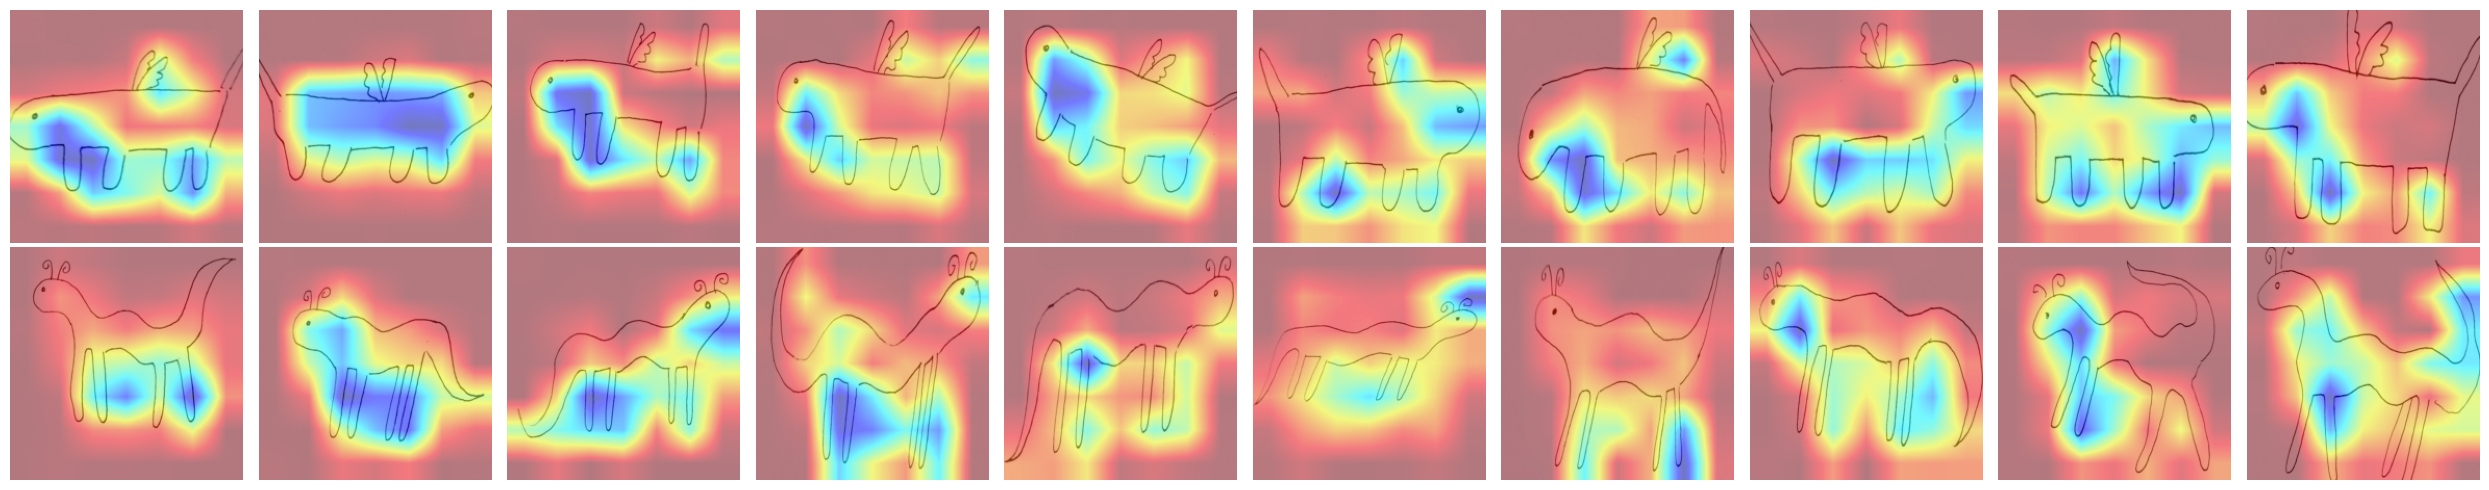

In [10]:
# All visualizations
fig, axes = plt.subplots(2, 10, figsize=(25,5))
for i in range(10):
    shorse_features, shorse_image = image_process(f"images/shorse-{i+1}.jpg")
    snarse_features, snarse_image = image_process(f"images/snarse-{i+1}.jpg")
    
    shorse_cam = cam(input_tensor=shorse_features)
    shorse_vis = show_cam_on_image(shorse_image, mask=shorse_cam[0, :])

    snarse_cam = cam(input_tensor=snarse_features)
    snarse_vis = show_cam_on_image(snarse_image, mask=snarse_cam[0, :])

    axes[0, i].imshow(shorse_vis)
    axes[0, i].axis('off')

    axes[1, i].imshow(snarse_vis)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


What do you think?

Are these parts what you looked at when you were drawing your snarse?